In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import lognorm

# Stochastic Asset Price Modeling: Foundations of the Black-Scholes-Merton Model

This notebook explores the theoretical and practical foundations of the Black-Scholes-Merton (BSM) model, bridging the rigorous quantitative frameworks of John Hull's *Options, Futures, and Other Derivatives* with clean, discrete-time Python implementations.

To understand how we price derivative contracts under the BSM framework, we begin by looking at the price of a stock through a magnifying glass, modeling its dynamics one step at a time. Under Geometric Brownian Motion (GBM), we assume that a stock price $S_t$ follows a continuous-time stochastic differential equation (SDE) defined by:

$$dS_t = \mu S_t dt + \sigma S_t dW_t$$

Here, $\mu$ represents the deterministic drift (the expected rate of return of the asset), while $\sigma$ captures the random volatility driven by a standard Wiener process $dW_t$. In a computer simulation, we must discretize this continuous-time process. Over a tiny time slice $\Delta t$, this translates to updating the stock price by multiplying the previous price by a combination of a steady growth trend and a random volatility shock:

`S_path[:, t] = S_path[:, t-1] * (1 + mu * dt + sigma * np.sqrt(dt) * Z)`

An intuitive way to visualize this path is by tracking the growth of a tree over a year. The tree has a natural biological growth rate—this is our drift $\mu \Delta t$. At the same time, it is constantly buffeted by daily, unpredictable gusts of wind—this is our random volatility shock $\sigma \sqrt{\Delta t} Z$, where $Z \sim N(0, 1)$ represents a standard normal variable. Sometimes the wind pushes the branches upward, aiding growth, and sometimes it hits from above, slowing it down. 

At the end of the year, the accumulation of these tiny, independent daily shocks shapes the tree's final height. Because these daily percentage changes are normally distributed and compound over time, the final heights of thousands of identical trees will follow an asymmetrical, lognormal distribution, naturally bounded at zero. This lognormal behavior is a cornerstone of option pricing: while daily returns follow a classic normal bell curve, the absolute stock prices compound into a lognormal distribution. If we take the natural logarithm ($\ln$) of these simulated terminal prices, they snap right back into a perfect, symmetric normal distribution.

However, the expected return $\mu$ that we input is not what we realize in practice due to a phenomenon known as **volatility drag** (or variance drag). In stochastic compounding, the realized geometric growth rate is eroded by the asset's variance, resulting in an actual growth rate of $\mu - \sigma^2/2$. 

To picture this erosion, imagine driving a car at a constant speedometer speed of 100 km/h. If you are on a straight highway, after one hour you will have traveled exactly 100 km down the map. But if the road is extremely winding and full of sharp curves, your speedometer might still average 100 km/h, but because you are constantly turning left and right, your net straight-line progress on the map will be significantly less. Volatility is the "zig-zag" of the road; the more curves there are, the more forward progress you lose. A highly volatile fund that swings up 50% one year and down 50% the next actually loses capital, dropping from $100 to $150 and then to $75, despite having a simple average return of zero. In our simulation, the mean of the simulated log-prices `np.mean(ln_ST_simulated)` converges to the theoretical average $\ln(S_0) + (\mu - \sigma^2/2)T$, showing this drag in action.

Another crucial mathematical characteristic of this volatility is how it scales over time. In a random walk (Wiener process), variance scales linearly with time ($Var[W_t] = t$), which means that uncertainty—measured by standard deviation—grows with the **square root of time ($\sqrt{T}$)**.

This diffusion process behaves much like an excited puppy on a retractable leash in an open park. In one minute, the puppy might run in a random direction and wander 5 meters away from you. But in four minutes, because the puppy constantly loops back and changes directions, he won't be 20 meters away; statistically, he will only be about 10 meters away ($\sqrt{4} = 2$ times the initial distance).

When calculating historical volatility from daily returns, we act on this principle: we find the standard deviation of daily log-returns $u_i = \ln(S_i / S_{i-1})$ and annualize it by multiplying by $\sqrt{252}$ to project the daily wiggles into a yearly scale. Let's run a simulation to verify if the log of our simulated prices indeed follows this normal bell curve.

Let's use some numbers the book have given us and have a look at the ln of the simulated price, to check if it does look like a normal distribution:

Simulated Mean of ln(ST): 3.8298
Theoretical Mean (Eq 15.3): 3.8289


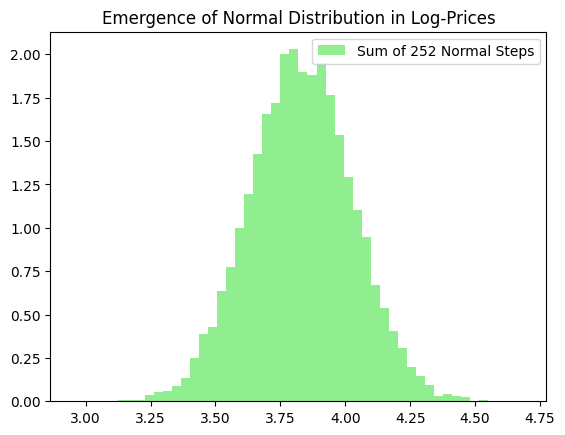

In [2]:
S0 = 40
mu = 0.16
sigma = 0.2
T = 1.0
n_steps = 252 # Daily steps over 1 year
dt = T / n_steps
n_sims = 10000

# We only use Equation 15.1: dS = S * (mu*dt + sigma*sqrt(dt)*Z)
S_path = np.full((n_sims, n_steps + 1), float(S0))

for t in range(1, n_steps + 1):
 Z = np.random.standard_normal(n_sims)
 # Applying the "Normal" percentage change rule from Equation 15.1
 # mu * dt is the drift
 # sigma * np.sqrt(dt) * Z is the random volatility
 S_path[:, t] = S_path[:, t-1] * (1 + mu * dt + sigma * np.sqrt(dt) * Z)

ST_simulated = S_path[:, -1]
ln_ST_simulated = np.log(ST_simulated)

# 2. Comparison with Theoretical Equation 15.3
theory_mean = np.log(S0) + (mu - 0.5 * sigma**2) * T
print(f"Simulated Mean of ln(ST): {np.mean(ln_ST_simulated):.4f}")
print(f"Theoretical Mean (Eq 15.3): {theory_mean:.4f}")

plt.hist(ln_ST_simulated, bins=50, density=True, color='lightgreen', label='Sum of 252 Normal Steps')
plt.title("Emergence of Normal Distribution in Log-Prices")
plt.legend()
plt.show()

We can also check the square root rule as follows:

In [3]:
S0, mu, sigma = 40, 0.16, 0.2
n_sims = 10000

def simulate_log_prices(T_years):
 n_steps = int(252 * T_years) # Daily steps
 dt = T_years / n_steps
 S = np.full(n_sims, float(S0))
 
 for t in range(n_steps):
 Z = np.random.standard_normal(n_sims)
 S = S * (1 + mu * dt + sigma * np.sqrt(dt) * Z)
 
 return np.log(S)

# Compare 1 Year vs 4 Years
ln_ST_1yr = simulate_log_prices(T_years=1.0)
ln_ST_4yr = simulate_log_prices(T_years=4.0)

std_1yr = np.std(ln_ST_1yr)
std_4yr = np.std(ln_ST_4yr)

print(f"Standard Deviation (1 Year): {std_1yr:.4f}")
print(f"Standard Deviation (4 Years): {std_4yr:.4f}")
print(f"Ratio (4yr / 1yr): {std_4yr / std_1yr:.4f}")
print(f"Theoretical Target (sqrt(4)): 2.0000")

Standard Deviation (1 Year): 0.1995
Standard Deviation (4 Years): 0.3970
Ratio (4yr / 1yr): 1.9901
Theoretical Target (sqrt(4)): 2.0000


## 4. Trading Days vs. Calendar Days Convention

When annualizing volatility, a practical question arises: does an asset's price continue to fluctuate over weekends and holidays when the market is closed? Empirical research (such as French, 1980) shows that volatility is driven by the flow of information and active trading, meaning prices vary significantly less over non-trading days. 

Think of it like a theme park ride that only experiences wear and tear when the park is open and people are actively riding it; when the park is closed, the ride sits idle and unchanged. Because of this, standard financial conventions ignore weekends and holidays, utilizing **252 trading days per year** instead of 365 calendar days for all volatility and time-decay calculations.

---

## 5. Delta-Hedging and the Black-Scholes-Merton Partial Differential Equation (PDE)

This leads us to the heart of the Black-Scholes-Merton model: the concept of **delta hedging**. The breakthrough of BSM was showing that we can build a locally riskless portfolio by combining a long position in the underlying stock with a short position in the option in an exact ratio known as Delta ($\Delta = \frac{\partial f}{\partial S}$).

We can visualize this as a perfectly balanced see-saw. On one side, we place stock shares, and on the other, we place options. Since the option's price moves in tandem with the stock but at a smaller rate (e.g., a Delta of 0.4 means the option moves $0.40 for every $1.00 move in the stock), buying 40 shares and shorting 100 options keeps the see-saw perfectly level. If the stock price rises, the gain on the shares matches the loss on the short options. Because the see-saw does not move, the portfolio carries no local risk. By no-arbitrage, this risk-free portfolio must grow at the same rate as a secure bank account (the risk-free rate, $r$).

This equilibrium is mathematically formalized in the BSM Partial Differential Equation:

$$\frac{\partial f}{\partial t} + rS \frac{\partial f}{\partial S} + \frac{1}{2} \sigma^2 S^2 \frac{\partial^2 f}{\partial S^2} = rf$$

This equation elegantly balances three forces: the decay of the option's value over time (Theta, $\frac{\partial f}{\partial t}$), the drift of the underlying stock ($rS \frac{\partial f}{\partial S}$), and the convex adjustment gained from the stock's random wiggles (Gamma, $\frac{1}{2} \sigma^2 S^2 \frac{\partial^2 f}{\partial S^2}$), all adding up to the risk-free return of the option ($rf$). In the Python code below, we verify how this balance holds.

We can use Python to prove that this balanced see-saw actually works. If we balance it right, our total money stays the same (plus a little interest) no matter what the stock does.


In [4]:
# Setup
S0 = 40.00
delta = 0.4 # The "Slope" of the see-saw
num_options = 100
num_shares = 40 # To balance: 100 * 0.4

# Scenario: The Stock moves up by 10 cents
dS = 0.10
gain_on_shares = num_shares * dS # You made $4.00

# Scenario: The Option price follows the slope (0.4 * 0.10)
dc = delta * dS 
loss_on_short_options = num_options * dc # You lost $4.00

# The Result
net_change = gain_on_shares - loss_on_short_options
print(f"Net change in see-saw: ${net_change:.2f}") 
# Result: $0.00! The risk is gone.

Net change in see-saw: $-0.00


## 6. Analytical Pricing under Risk-Neutral Valuation

Because we can perfectly hedge away the stock's directional risk, option pricing operates under a powerful framework called **risk-neutral valuation**. Since risk preferences do not affect the final replication price, we can price derivatives by assuming a world where everyone is risk-neutral and all assets grow at the risk-free rate $r$. This gives us the famous analytical BSM call formula:

$$c = S_0 N(d_1) - Ke^{-rT} N(d_2)$$

The formula is essentially a probability-weighted balance. The term $N(d_2)$ represents the risk-neutral probability that the option will expire in-the-money, acting like a weather forecast predicting a 60% chance of rain. The term $N(d_1)$ is slightly more complex, representing the expected asset value conditional on expiring in-the-money (analogous to the amount of rain expected if it does storm). The formula simply takes what we expect to receive ($S_0 N(d_1)$) and subtracts the present value of the strike price we must pay ($K e^{-rT} N(d_2)$), adjusted for those probabilities.

In practice, while we can observe the option's market price, we cannot directly observe volatility ($\sigma$). We work backward instead: we take the market price and numerically invert the BSM formula (using root-finding algorithms like Newton-Raphson) to find the **implied volatility (IV)**—the market's consensus on the asset's future wiggles, much like estimating the speed of a toy car's motor by observing how fast it travels.

Furthermore, we must distinguish exchange-traded options from company-issued **warrants**. When a company issues warrants, the future exercise will lead to the creation of new shares, diluting the company's equity. This dilutive effect behaves like inviting more friends to share a pizza: a pizza cut into 4 slices now has to be cut into 6, making everyone's slice smaller. We adjust the BSM formula by multiplying the call price by the dilution factor $\frac{N}{N + M}$ to reflect this. Below, we implement the BSM pricing function.

We can use a special library called `scipy` to act as our calculator for these formulas. We'll do an example below.


In [5]:
def black_scholes_call(S, K, T, r, sigma):
 # d1 and d2 are the "logic steps" of the formula
 d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
 d2 = d1 - sigma * np.sqrt(T)
 
 # norm.cdf is the N(x) from the book (the bell curve probability)
 call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
 return call_price

# Example from the book (Example 15.6)
# S=42, K=40, r=0.1, sigma=0.2, T=0.5
price = black_scholes_call(42, 40, 0.5, 0.1, 0.2)
print(f"The price is: ${price:.2f}")


The price is: $4.76


## 8. Dividend Adjustments and the Early Exercise Boundary

So far, we have assumed the underlying asset does not pay dividends. However, when a company pays a dividend, its stock price drops on the ex-dividend date by the amount of the payout. For a European option, since we cannot exercise early, any dividends paid during the option's life are lost. This is like buying an apple tree and knowing that a ripe apple (the dividend) will fall and be kept by the seller before you can take the tree home—the tree you receive is worth less. We adjust the model by subtracting the present value of all expected dividends from the current stock price to find the adjusted price:

$$S^* = S_0 - \sum D_i e^{-r t_i}$$

For American options, the ability to exercise early introduces a critical decision boundary. While it is never optimal to exercise an American call early on a non-dividend stock, it can be rational to exercise immediately *before* an ex-dividend date to capture a large dividend. This is the greedy choice: if a massive fruit is about to fall off the tree, you use your ticket a second early to secure both the tree and the fruit.

Since pricing American options analytically is difficult, **Black's Approximation** provides an elegant shortcut. It evaluates two European options: one maturing at the actual expiration ($T$) using the fully adjusted stock price $S^*$, and another maturing just before the final ex-dividend date ($t_n$) using a stock price adjusted only for dividends paid before $t_n$. The American option is valued as the maximum of these two:

$$C_{American} \approx \max \left( c(S^*, K, T), c(S_0 - \text{PV of divs prior to } t_n, K, t_n) \right)$$

In the final code block, we compare these European and American call prices.


In [6]:

def bsm_call(S, K, T, r, sigma):
 if T <= 0: return max(0, S - K)
 d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
 d2 = d1 - sigma*np.sqrt(T)
 return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# European Calculation ---
S0, K, r, sigma, T = 40, 40, 0.09, 0.30, 0.5
# PV of dividends: 0.50*e^(-0.09 * 2/12) + 0.50*e^(-0.09 * 5/12)
pv_divs = (0.50 * np.exp(-0.09 * 2/12)) + (0.50 * np.exp(-0.09 * 5/12))
S_star = S0 - pv_divs

euro_call = bsm_call(S_star, K, T, r, sigma)

# American Approximation (Black's) ---
# Price maturity at last dividend date (tn = 5/12)
# Only subtract dividends that happen BEFORE tn
S_star_tn = S0 - (0.50 * np.exp(-0.09 * 2/12))
call_tn = bsm_call(S_star_tn, K, 5/12, r, sigma)

american_call = max(euro_call, call_tn)

print(f"Adjusted Stock Price (S*): {S_star:.4f}")
print(f"European Call Price: {euro_call:.4f}")
print(f"American Call Price (Black's Approx): {american_call:.4f}")

Adjusted Stock Price (S*): 39.0258
European Call Price: 3.6712
American Call Price (Black's Approx): 3.6712
